## Week 18

## Unsupervised learning


Unsupervised Learning is a type of Machine Learning where:  

The data has no labels (no correct answers)   
The model learns by finding patterns on its own  

“Unsupervised learning means learning from data without being told the correct output.”

##### Unsupervised learning म्हणजे unlabeled data मधून model स्वतःच patterns learn करतो.

### 1️⃣ Clustering

Group similar data points together

👉 Same cluster = high similarity  
👉 Different clusters = low similarity

Similar data group करणे

- #### Popular Algorithms:

K-Means  
Hierarchical Clustering  
DBSCAN  

#### Example: Customer segmentation



समजा:

Students चा data आहे (marks, height, etc.)  
पण कोण “good” किंवा “average” आहे ते दिलेलं नाही

👉 Model काय करेल?

Similar students एकत्र group करेल

✔ High marks → एक group  
✔ Low marks → दुसरा group

👉 याला म्हणतात Clustering

- #### K-means

K-Means मध्ये:

Data ला K groups (clusters) मध्ये divide करतो  
Similar data points → same cluster

Cluster Labels: [1 1 1 0 0 0]
Centroids:
 [[ 42.33333333 160.        ]
 [ 87.66666667 172.33333333]]


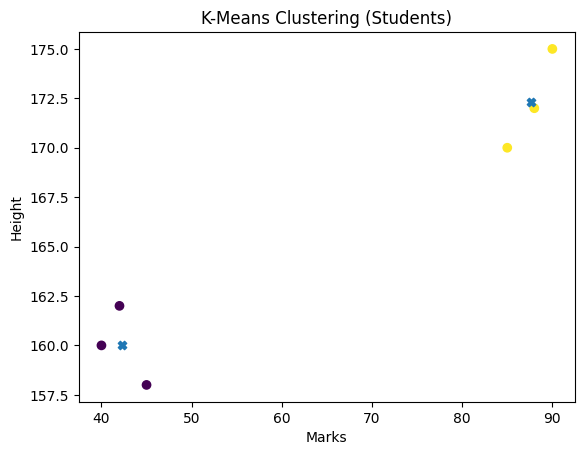

In [11]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Students data [marks, height]
X = np.array([
    [85,170],
    [90,175],
    [88,172],
    [40,160],
    [45,158],
    [42,162]
])

# Step 2: Create model (2 clusters)
kmeans = KMeans(n_clusters=2, random_state=0)

# Step 3: Train model
kmeans.fit(X)

# Step 4: Output
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

print("Cluster Labels:", labels)
print("Centroids:\n", centroids)

# Step 5: Visualization
plt.scatter(X[:,0], X[:,1], c=labels)
plt.scatter(centroids[:,0], centroids[:,1], marker='X')
plt.xlabel("Marks")
plt.ylabel("Height")
plt.title("K-Means Clustering (Students)")
plt.show()

- #### Heirarchical Clusturing

Hierarchical clustering मध्ये:

सुरुवातीला प्रत्येक point = separate cluster  
नंतर nearest clusters merge करतो

👉 शेवटी tree structure (Dendrogram) तयार होतो

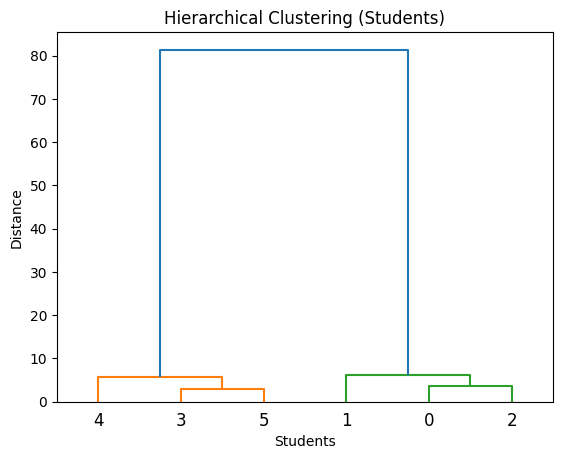

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
import numpy as np

# Students data [marks, height]
X = np.array([
    [85,170],
    [90,175],
    [88,172],
    [40,160],
    [45,158],
    [42,162]
])

# Step 1: Apply linkage
Z = linkage(X, method='ward')

# Step 2: Plot dendrogram
dendrogram(Z)
plt.title("Hierarchical Clustering (Students)")
plt.xlabel("Students")
plt.ylabel("Distance")
plt.show()

- #### DBSCAN

DBSCAN हा एक clustering algorithm आहे जो:

density (घनता) वर आधारित clusters तयार करतो  
आणि outliers (noise) पण detect करतो

जिथे points जास्त जवळ आहेत → cluster, दूर असलेले → noise

Cluster Labels: [0 0 0 1 1 1]


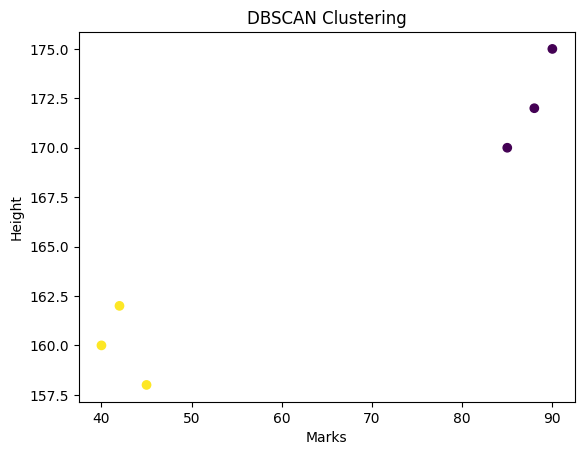

In [10]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Students data
X = np.array([
    [85,170],
    [90,175],
    [88,172],
    [40,160],
    [45,158],
    [42,162]
])

# Model
db = DBSCAN(eps=5, min_samples=2)

# Train
labels = db.fit_predict(X)

print("Cluster Labels:", labels)

# Visualization
plt.scatter(X[:,0], X[:,1], c=labels)
plt.xlabel("Marks")
plt.ylabel("Height")
plt.title("DBSCAN Clustering")
plt.show()

### 2️⃣ Association

“If this happens → then that also happens”

👉 Items मधील relation शोधणे  

- #### Algorithm:

Apriori Algorithm

#### Example: 
Market basket



Shopping Example

Supermarket मध्ये:

Customers काय घेतात त्याचा data आहे

👉 Model find करतो:

“Chips घेतले तर cold drink पण घेतात”

👉 याला म्हणतात Association

- #### Apriori Algorithm

Apriori Algorithm हा एक algorithm आहे जो:

frequent itemsets (वारंवार येणारे items) शोधतो  
आणि त्यातून association rules तयार करतो

Data मधून वारंवार येणारे items शोधून त्यांच्यातील संबंध (rules) काढतो

In [12]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# Step 1: Transaction Data (Supermarket)
data = {
    'Chips':        [1, 1, 0, 1, 0],
    'Cold Drink':   [1, 1, 1, 0, 0],
    'Biscuits':     [0, 1, 1, 1, 0],
    'Chocolate':    [1, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

print("Dataset:\n", df)

# Step 2: Find Frequent Itemsets
freq_items = apriori(df, min_support=0.4, use_colnames=True)

print("\nFrequent Itemsets:\n", freq_items)

# Step 3: Generate Association Rules
rules = association_rules(freq_items, metric="confidence", min_threshold=0.6)

print("\nAssociation Rules:\n", rules)

Dataset:
    Chips  Cold Drink  Biscuits  Chocolate
0      1           1         0          1
1      1           1         1          0
2      0           1         1          1
3      1           0         1          1
4      0           0         0          1

Frequent Itemsets:
    support                 itemsets
0      0.6                  (Chips)
1      0.6             (Cold Drink)
2      0.6               (Biscuits)
3      0.8              (Chocolate)
4      0.4      (Cold Drink, Chips)
5      0.4        (Biscuits, Chips)
6      0.4       (Chocolate, Chips)
7      0.4   (Biscuits, Cold Drink)
8      0.4  (Chocolate, Cold Drink)
9      0.4    (Chocolate, Biscuits)

Association Rules:
     antecedents   consequents  antecedent support  consequent support  \
0  (Cold Drink)       (Chips)                 0.6                 0.6   
1       (Chips)  (Cold Drink)                 0.6                 0.6   
2    (Biscuits)       (Chips)                 0.6                 0.6   
3       

C:\Users\jadha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


### 3️⃣ Dimensionality Reduction

👉 Features कमी करणे

- #### Algorithms:

PCA (Principal Component Analysis)  
t-SNE

#### Example:    
- Big data simplify करणे  
- Image compression  
- Data visualization

- #### PCA:

What is PCA?

👉 PCA हा एक technique आहे जो:

Data मधील features (columns) कमी करतो  
पण important information (variance) जपून ठेवतो

In [13]:
from sklearn.decomposition import PCA
import numpy as np

# Data
X = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])

# PCA
pca = PCA(n_components=2)
X_new = pca.fit_transform(X)

print("Reduced Data:\n", X_new)

Reduced Data:
 [[-5.19615242e+00 -2.56395025e-16]
 [ 0.00000000e+00 -0.00000000e+00]
 [ 5.19615242e+00 -2.56395025e-16]]


- #### t-SNE:

What is t-SNE?

👉 t-SNE हा technique आहे जो:

High-dimensional data → 2D/3D मध्ये convert करतो  
Visualization साठी best आहे

t-SNE Output:
 [[1080.7062      0.      ]
 [ -19.816063    0.      ]
 [ 307.85825     0.      ]
 [ 752.80035     0.      ]]


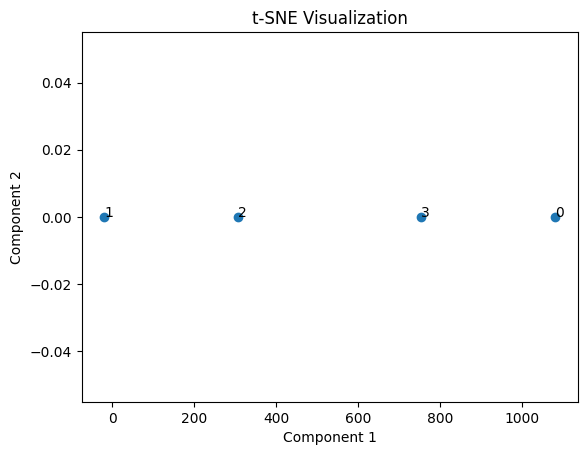

In [16]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Data
X = np.array([[1,2,3],
              [4,5,6],
              [7,8,9],
              [2,3,4]])

# t-SNE (fixed perplexity)
tsne = TSNE(n_components=2, perplexity=2, random_state=0)

X_new = tsne.fit_transform(X)

print("t-SNE Output:\n", X_new)

# 📊 Plot Graph
plt.scatter(X_new[:,0], X_new[:,1])

# Label each point
for i, txt in enumerate(range(len(X_new))):
    plt.annotate(txt, (X_new[i,0], X_new[i,1]))

plt.title("t-SNE Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()